# 신용카드 이상거래 탐지 프로젝트 (전처리 + Feature Engineering 중심)

- 작성일: 2026-02-19
- **평가 목표**
  1. 컬럼 이름 변경이 명확하게 반영되고, 다양한 방법으로 효과적인 결측치 처리를 진행
  2. 데이터 내 이상치를 감지하고 수정하며, 수정 후 일관성/품질 향상 확인
  3. 주어진 변수에서 **유용한 파생변수(Feature Engineering)** 생성

> 본 노트북은 **모델 성능 경쟁**이 목적이 아니라, 전처리/품질 개선/변수 생성 과정을 명확히 보여주는 데 초점을 둡니다.


## Step 0) 환경 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)


## Step A) Raw Data 로딩 및 기본 확인

In [2]:
DATA_PATH = "fraud.csv"  # 제공된 raw data
df_raw = pd.read_csv(DATA_PATH)

print("shape:", df_raw.shape)
display(df_raw.head())


shape: (491134, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [3]:
print("columns:", df_raw.columns.tolist())
display(df_raw.dtypes.to_frame("dtype"))

missing = df_raw.isna().mean().sort_values(ascending=False)
display((missing*100).to_frame("missing_%").head(20))


columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,dtype
trans_date_trans_time,str
cc_num,int64
merchant,str
category,str
amt,float64
first,str
last,str
gender,str
street,str
city,str


,missing_%
trans_date_trans_time,0.0
cc_num,0.0
merchant,0.0
category,0.0
amt,0.0
first,0.0
last,0.0
gender,0.0
street,0.0
city,0.0


## Step A-2) 컬럼명 정리 (명확한 rename)

In [4]:
df = df_raw.copy()

KEY_COL = "cc_num"                  # 사용자 확인 완료
TIME_COL_RAW = "trans_date_trans_time"
TARGET = "is_fraud"
AMT_COL = "amt"

rename_map = {
    TIME_COL_RAW: "trans_datetime",
    "city_pop": "city_population",
}
df = df.rename(columns=rename_map)

TIME_COL = "trans_datetime"

print("Renamed columns check:")
for c in [KEY_COL, TIME_COL, TARGET, AMT_COL]:
    print(c, "->", (c in df.columns))

display(df[[KEY_COL, TIME_COL, TARGET, AMT_COL]].head())


Renamed columns check:
cc_num -> True
trans_datetime -> True
is_fraud -> True
amt -> True


,cc_num,trans_datetime,is_fraud,amt
0,630423337322,2019-01-01 00:00:44,0,107.23
1,4956828990005111019,2019-01-01 00:12:34,0,44.71
2,180048185037117,2019-01-01 00:17:16,0,46.28
3,374930071163758,2019-01-01 00:20:15,0,64.09
4,2712209726293386,2019-01-01 00:23:41,0,25.58


## Step B) 결측치 처리 (여러 방식 적용 + 근거 기록)

- 수치형: 중앙값(median) 대체 (이상치에 robust)  
- 범주형: 최빈값(mode) 대체  
- 시간형: 파싱 실패(NaT)는 제거(시간기반 파생변수 생성 불가)  
- 결측 indicator: 결측 여부 자체가 신호일 수 있어 0/1 변수 추가  


In [5]:
# 1) 시간 컬럼 파싱 (실패는 NaT)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

print("TIME null count:", df[TIME_COL].isna().sum())

# 시간 파싱 실패는 제거
df = df[df[TIME_COL].notna()].copy()
df = df.sort_values([KEY_COL, TIME_COL]).reset_index(drop=True)
print("after time cleaning shape:", df.shape)


TIME null count: 0
after time cleaning shape: (491134, 22)


In [6]:
# 2) 결측 indicator 생성(결측이 있는 컬럼에 대해서만)
missing_cols = df.columns[df.isna().any()].tolist()
print("missing columns:", missing_cols)

for c in missing_cols:
    df[f"{c}_is_missing"] = df[c].isna().astype(int)

print("indicator count:", len([c for c in df.columns if c.endswith("_is_missing")]))


missing columns: []
indicator count: 0


In [7]:
# 3) 결측치 대체: 수치형=중앙값, 범주형=최빈값
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != TIME_COL]

for c in [TARGET, KEY_COL]:
    if c in num_cols: num_cols.remove(c)
    if c in cat_cols: cat_cols.remove(c)

# 수치형
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# 범주형
for c in cat_cols:
    if df[c].isna().any():
        mode = df[c].mode(dropna=True)
        fillv = mode.iloc[0] if len(mode) else "UNKNOWN"
        df[c] = df[c].fillna(fillv)

missing_after = df.isna().mean().sort_values(ascending=False)
display((missing_after*100).to_frame("missing_%").head(20))


,missing_%
trans_datetime,0.0
cc_num,0.0
merchant,0.0
category,0.0
amt,0.0
first,0.0
last,0.0
gender,0.0
street,0.0
city,0.0


## Step C) 이상치 탐지 및 수정 (amt 중심)

- IQR 기준으로 이상치를 탐지하고, **Winsorizing(클리핑)** 으로 극단값을 완화합니다.  
- 수정 전/후 분포와 요약 통계를 비교하여 품질 향상을 확인합니다.


amt IQR bounds: -98.095 187.385
outlier rate: 0.07085642614846457


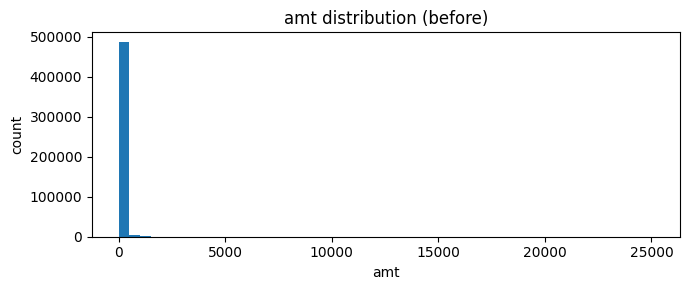

In [8]:
amt = df[AMT_COL].astype(float)

q1, q3 = amt.quantile(0.25), amt.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("amt IQR bounds:", lower, upper)
print("outlier rate:", ((amt < lower) | (amt > upper)).mean())

plt.figure(figsize=(7,3))
plt.hist(amt, bins=50)
plt.title("amt distribution (before)")
plt.xlabel("amt"); plt.ylabel("count")
plt.tight_layout(); plt.show()


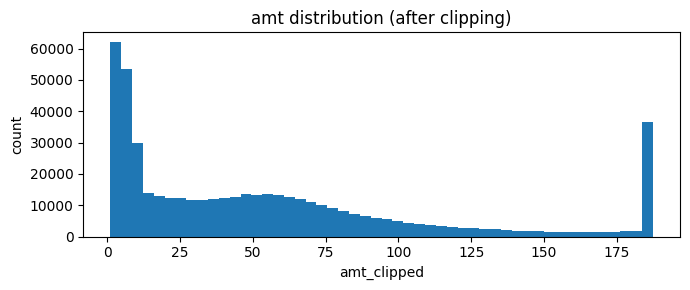

,before_amt,after_amt_clipped
count,491134.000000,491134.000000
mean,69.050120,56.399058
std,160.322867,55.107145
min,1.000000,1.000000
25%,8.960000,8.960000
50%,42.170000,42.170000
75%,80.330000,80.330000
max,25086.940000,187.385000


In [9]:
df["amt_clipped"] = df[AMT_COL].clip(lower=lower, upper=upper)

plt.figure(figsize=(7,3))
plt.hist(df["amt_clipped"], bins=50)
plt.title("amt distribution (after clipping)")
plt.xlabel("amt_clipped"); plt.ylabel("count")
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "before_amt": df[AMT_COL].describe(),
    "after_amt_clipped": df["amt_clipped"].describe()
})
display(summary)


## Step D) Feature Engineering (유용한 파생변수 생성)

- 시간 파생: hour/dayofweek/is_weekend  
- 고객별 거래 간격: since_prev_txn_sec  
- Rolling(과거만): 1h, 1d, 7d 거래수/누적금액 (누수 방지: closed='left')  


In [10]:
# 시간 파생
df["txn_hour"] = df[TIME_COL].dt.hour
df["txn_dayofweek"] = df[TIME_COL].dt.dayofweek
df["is_weekend"] = (df["txn_dayofweek"] >= 5).astype(int)

# 고객별 거래 간격(초)
df["since_prev_txn_sec"] = (
    df.groupby(KEY_COL)[TIME_COL].diff().dt.total_seconds().fillna(0)
)

display(df[[KEY_COL, TIME_COL, "txn_hour", "txn_dayofweek", "is_weekend", "since_prev_txn_sec"]].head(10))


,cc_num,trans_datetime,txn_hour,txn_dayofweek,is_weekend,since_prev_txn_sec
0,503874407318,2019-01-01 04:34:51,4,1,0,0.0
1,503874407318,2019-01-01 14:14:18,14,1,0,34767.0
2,503874407318,2019-01-01 20:49:42,20,1,0,23724.0
3,503874407318,2019-01-01 21:23:54,21,1,0,2052.0
4,503874407318,2019-01-02 11:49:04,11,2,0,51910.0
5,503874407318,2019-01-03 09:18:53,9,3,0,77389.0
6,503874407318,2019-01-03 10:15:45,10,3,0,3412.0
7,503874407318,2019-01-03 11:52:45,11,3,0,5820.0
8,503874407318,2019-01-03 19:46:22,19,3,0,28417.0
9,503874407318,2019-01-03 20:35:57,20,3,0,2975.0


In [11]:
# Rolling feature (time window)
df = df.sort_values([KEY_COL, TIME_COL]).reset_index(drop=True)
df = df.set_index(TIME_COL)

windows = {"1h": "1h", "1d": "1d", "7d": "7d"}

for tag, win in windows.items():
    df[f"cc_txn_cnt_{tag}"] = (
        df.groupby(KEY_COL)["amt_clipped"]
          .rolling(win, closed="left")
          .count()
          .reset_index(level=0, drop=True)
          .fillna(0)
    )
    df[f"cc_amt_sum_{tag}"] = (
        df.groupby(KEY_COL)["amt_clipped"]
          .rolling(win, closed="left")
          .sum()
          .reset_index(level=0, drop=True)
          .fillna(0)
    )

df = df.reset_index()
created = [c for c in df.columns if c.startswith("cc_")]
print("created rolling features:", created)
display(df[[TIME_COL, KEY_COL, "amt_clipped"] + created].head(10))


C:\Users\User\AppData\Local\Temp\ipykernel_10456\211368769.py:10: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling(win, closed="left")
C:\Users\User\AppData\Local\Temp\ipykernel_10456\211368769.py:17: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling(win, closed="left")
C:\Users\User\AppData\Local\Temp\ipykernel_10456\211368769.py:10: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling(win, closed="left")
C:\Users\User\AppData\Local\Temp\ipykernel_10456\211368769.py:17: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling(win, closed="left")


created rolling features: ['cc_num', 'cc_txn_cnt_1h', 'cc_amt_sum_1h', 'cc_txn_cnt_1d', 'cc_amt_sum_1d', 'cc_txn_cnt_7d', 'cc_amt_sum_7d']


,trans_datetime,cc_num,amt_clipped,cc_num,cc_txn_cnt_1h,cc_amt_sum_1h,cc_txn_cnt_1d,cc_amt_sum_1d,cc_txn_cnt_7d,cc_amt_sum_7d
0,2019-01-01 04:34:51,503874407318,63.89,503874407318,0.0,0.00,0.0,0.00,0.0,0.00
1,2019-01-01 14:14:18,503874407318,40.75,503874407318,0.0,0.00,1.0,63.89,1.0,63.89
2,2019-01-01 20:49:42,503874407318,105.78,503874407318,0.0,0.00,2.0,104.64,2.0,104.64
3,2019-01-01 21:23:54,503874407318,92.64,503874407318,1.0,105.78,3.0,210.42,3.0,210.42
4,2019-01-02 11:49:04,503874407318,28.43,503874407318,0.0,0.00,3.0,239.17,4.0,303.06
5,2019-01-03 09:18:53,503874407318,42.85,503874407318,0.0,0.00,1.0,28.43,5.0,331.49
6,2019-01-03 10:15:45,503874407318,56.55,503874407318,1.0,42.85,2.0,71.28,6.0,374.34
7,2019-01-03 11:52:45,503874407318,2.97,503874407318,0.0,0.00,2.0,99.40,7.0,430.89
8,2019-01-03 19:46:22,503874407318,15.49,503874407318,0.0,0.00,3.0,102.37,8.0,433.86
9,2019-01-03 20:35:57,503874407318,6.92,503874407318,1.0,15.49,4.0,117.86,9.0,449.35


## Step E) 시간 기준 Train/Test 분리 (누수 방지)

In [12]:
df = df.sort_values(TIME_COL).reset_index(drop=True)

split_point = df[TIME_COL].quantile(0.8)
train_df = df[df[TIME_COL] <= split_point].copy()
test_df  = df[df[TIME_COL] > split_point].copy()

print("Train period:", train_df[TIME_COL].min(), "->", train_df[TIME_COL].max())
print("Test  period:", test_df[TIME_COL].min(), "->", test_df[TIME_COL].max())
print("Train fraud rate:", train_df[TARGET].mean())
print("Test  fraud rate:", test_df[TARGET].mean())


Train period: 2019-01-01 00:00:44 -> 2020-08-25 15:18:33
Test  period: 2020-08-25 15:18:46 -> 2020-12-31 23:59:34
Train fraud rate: 0.00270801996401184
Test  fraud rate: 0.0018324900485609864


## Step F) 전처리/FE 결과 점검

In [13]:
missing_final = df.isna().sum().sort_values(ascending=False)
display(missing_final.head(20))

display(df[TARGET].value_counts())
print("fraud rate:", df[TARGET].mean())


trans_datetime     0
cc_num             0
merchant           0
category           0
amt                0
first              0
last               0
gender             0
street             0
city               0
state              0
zip                0
lat                0
long               0
city_population    0
job                0
dob                0
trans_num          0
unix_time          0
merch_lat          0
dtype: int64

is_fraud
0    489890
1      1244
Name: count, dtype: int64

fraud rate: 0.0025329136243876418


## Step G) 최소 모델링 (Feature 효과 확인용)

모델은 전처리/파생변수 효과 확인용으로만 실행합니다. 지표는 PR-AUC를 사용합니다.

In [14]:
# 숫자형 + 생성된 변수만 사용 (범주형 인코딩은 '최종 보고서 단계'에서 확장 가능)
feature_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c != TARGET]

# ID(cc_num)는 모델이 외울 수 있어 제외
if KEY_COL in feature_cols:
    feature_cols.remove(KEY_COL)

X_train = train_df[feature_cols]
y_train = train_df[TARGET].astype(int)
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET].astype(int)

print("n_features:", len(feature_cols))
print("top 20 features:", feature_cols[:20])


n_features: 19
top 20 features: ['amt', 'zip', 'lat', 'long', 'city_population', 'unix_time', 'merch_lat', 'merch_long', 'amt_clipped', 'txn_hour', 'txn_dayofweek', 'is_weekend', 'since_prev_txn_sec', 'cc_txn_cnt_1h', 'cc_amt_sum_1h', 'cc_txn_cnt_1d', 'cc_amt_sum_1d', 'cc_txn_cnt_7d', 'cc_amt_sum_7d']


In [15]:
lr = LogisticRegression(max_iter=200, n_jobs=-1, class_weight="balanced")
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:, 1]
ap_lr = average_precision_score(y_test, proba_lr)
print("✅ Baseline PR-AUC (LogReg):", ap_lr)


d:\011.DA_Projects\02.DA_PJT_1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✅ Baseline PR-AUC (LogReg): 0.015690663485957934


d:\011.DA_Projects\02.DA_PJT_1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=10
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
ap_rf = average_precision_score(y_test, proba_rf)
print("✅ RandomForest PR-AUC:", ap_rf)


✅ RandomForest PR-AUC: 0.45035697033883476


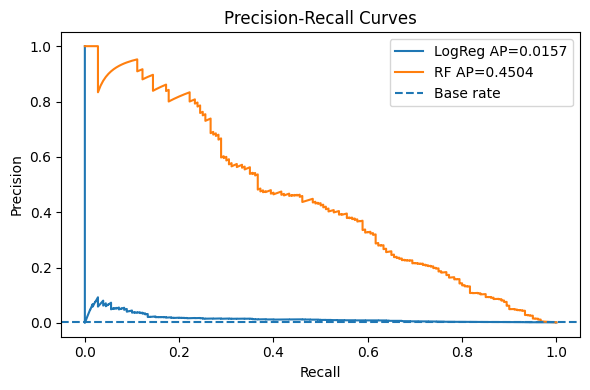

In [17]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, proba_rf)

plt.figure(figsize=(6,4))
plt.plot(rec_lr, prec_lr, label=f"LogReg AP={ap_lr:.4f}")
plt.plot(rec_rf, prec_rf, label=f"RF AP={ap_rf:.4f}")
plt.axhline(y_test.mean(), linestyle="--", label="Base rate")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()


## Step H) 제출용 체크리스트

- [x] 컬럼명 변경: `trans_date_trans_time → trans_datetime`, `city_pop → city_population`  
- [x] 결측치 처리: 수치(중앙값), 범주(최빈값), 결측 indicator 생성, 시간 파싱 실패 제거  
- [x] 이상치 처리: `amt` IQR 탐지 → 클리핑(winsorizing), 전/후 분포 비교  
- [x] 파생변수 생성: 시간 파생 + rolling(1h/1d/7d) + 거래 간격  
- [x] 누수 방지: rolling은 `closed='left'`, Train/Test는 시간 기준 분리  
